<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/02_deep_learning_foundations/14_dropout_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dropout Regularization

Dropout is one of the most popular regularization techniques used in Deep Learning.

Instead of allowing every neuron to participate in every training step, dropout randomly disables a fraction of neurons during training.

This forces the network to learn multiple independent representations rather than memorizing the training data.

Dropout is active only during training. During prediction, all neurons are used.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1],
    [0,0],
    [0,1],
    [1,0],
    [1,1],
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=float)

y = np.array([
    [0],[0],[0],[1],
    [0],[0],[0],[1],
    [0],[0],[0],[1]
], dtype=float)

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [4]:
model_without_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_without_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [5]:
history_without = model_without_dropout.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=0
)

In [6]:
model_with_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_with_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [7]:
history_with = model_with_dropout.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=0
)

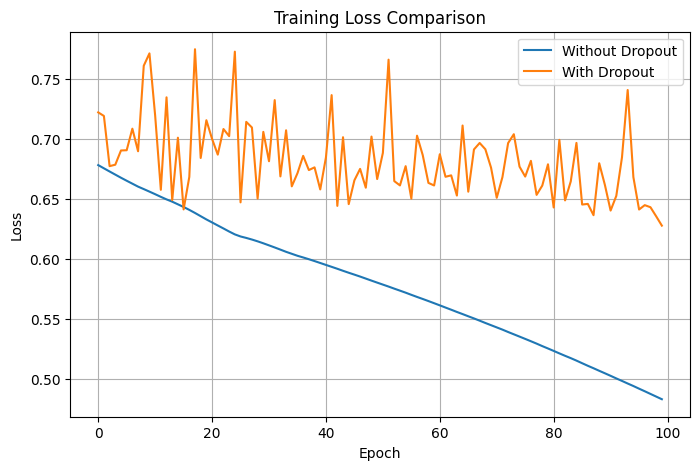

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history_without.history["loss"], label="Without Dropout")
plt.plot(history_with.history["loss"], label="With Dropout")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()

plt.show()

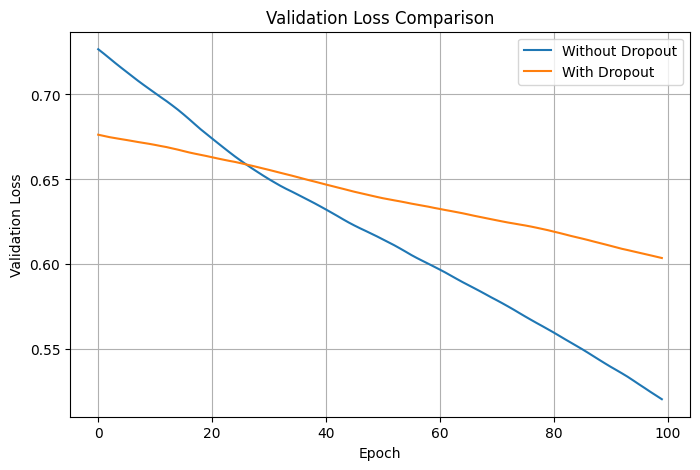

In [9]:
plt.figure(figsize=(8,5))

plt.plot(history_without.history["val_loss"], label="Without Dropout")
plt.plot(history_with.history["val_loss"], label="With Dropout")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid()

plt.show()

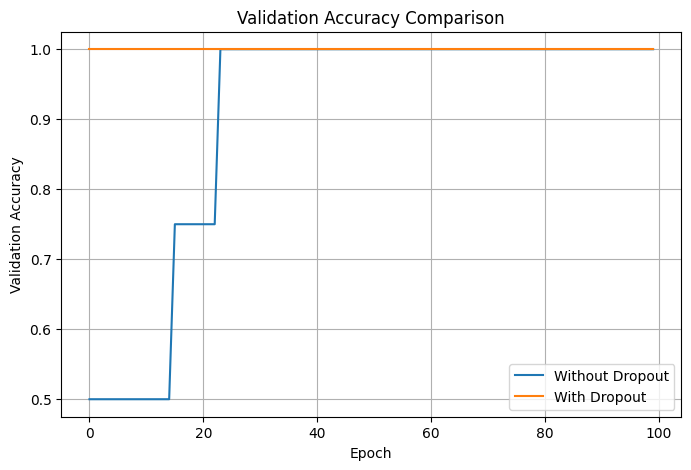

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history_without.history["val_accuracy"], label="Without Dropout")
plt.plot(history_with.history["val_accuracy"], label="With Dropout")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid()

plt.show()

In [11]:
import pandas as pd

dropout_table = pd.DataFrame({

    "Dropout Rate":[
        0.2,
        0.3,
        0.5
    ],

    "Typical Usage":[
        "Light Regularization",
        "Moderate Regularization",
        "Strong Regularization"
    ]

})

dropout_table

,Dropout Rate,Typical Usage
0,0.2,Light Regularization
1,0.3,Moderate Regularization
2,0.5,Strong Regularization


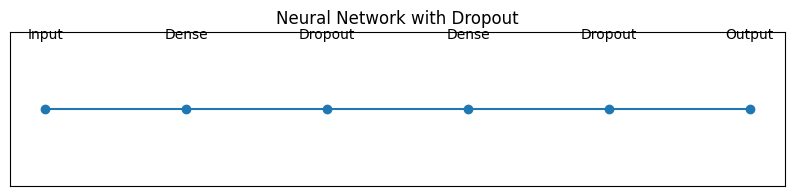

In [12]:
steps = [
    "Input",
    "Dense",
    "Dropout",
    "Dense",
    "Dropout",
    "Output"
]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Neural Network with Dropout")

plt.show()